In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [ ]:
X ,y = make_circles(n_samples = 100 , noise = 0.1 , random_state=1)

<Axes: >

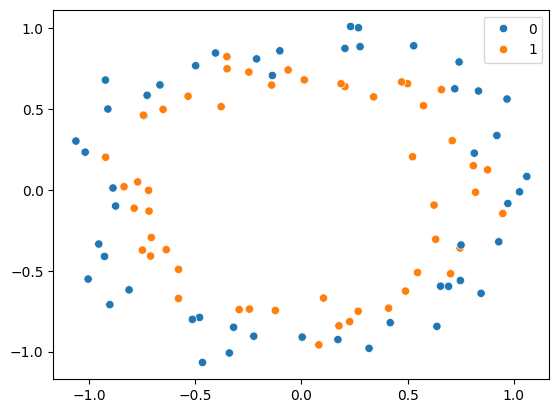

In [ ]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [ ]:
X_train ,X_test , y_train ,y_test = train_test_split(X,y,test_size=0.20,random_state=2)

In [ ]:
model = Sequential()
model.add(Dense(256,input_dim =2 , activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics = ['accuracy'])

In [ ]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs = 3500,verbose = 0)

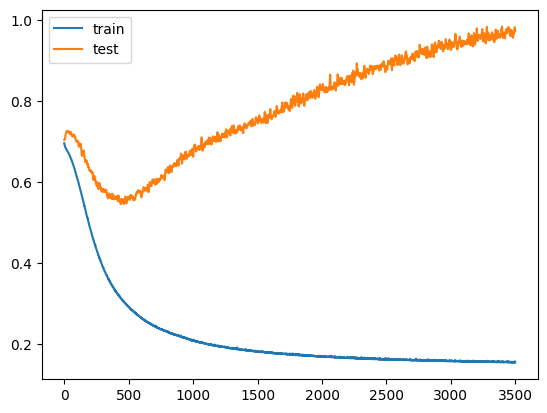

In [ ]:
plt.plot(history.history['loss'],label = 'train')
plt.plot(history.history['val_loss'],label ='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

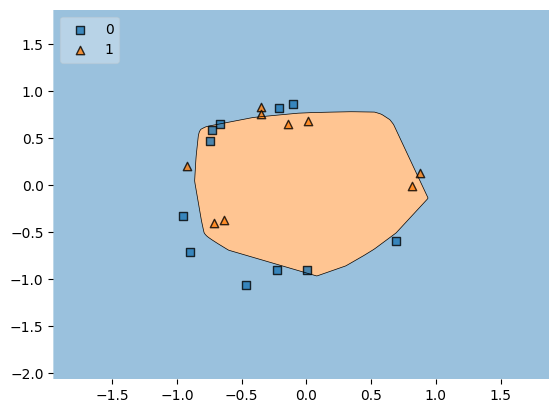

In [ ]:
plot_decision_regions(X_test , y_test.ravel(),clf = model,legend = 2)

Early Stopping

In [ ]:
model = Sequential()
model.add(Dense(256,input_dim =2,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics = ['accuracy'])

In [ ]:
callback = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0.00001,
    patience =20,
    verbose =1,
    mode ='auto',
    baseline = None,
    restore_best_weights = False
)

In [ ]:
history = model.fit(X_train,y_train,validation_data =(X_test ,y_test),epochs =3500,callbacks = callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.4875 - loss: 0.6959 - val_accuracy: 0.6000 - val_loss: 0.6911
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4500 - loss: 0.6925 - val_accuracy: 0.5500 - val_loss: 0.6939
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4750 - loss: 0.6914 - val_accuracy: 0.4500 - val_loss: 0.6969
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5125 - loss: 0.6911 - val_accuracy: 0.4500 - val_loss: 0.6992
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5375 - loss: 0.6897 - val_accuracy: 0.4500 - val_loss: 0.7008
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5375 - loss: 0.6889 - val_accuracy: 0.4500 - val_loss: 0.7011
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5375 - loss: 0.6879 - val_accuracy: 0.4500 - val_loss: 0.7013
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5625 - loss: 0.6873 - val_accuracy: 0.4000 - 

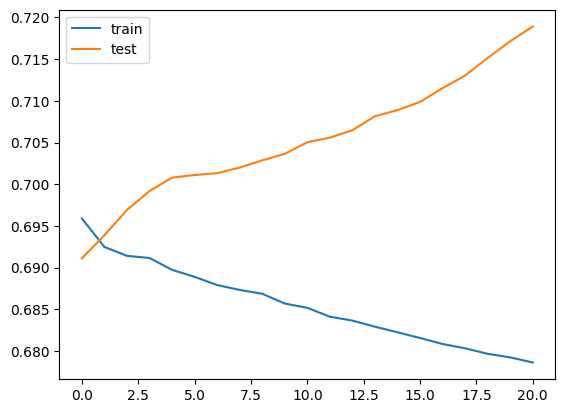

In [ ]:
plt.plot(history.history['loss'],label = 'train')
plt.plot(history.history['val_loss'],label = 'test')
plt.legend()
plt.show()